# Classification

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Motivation

- Least squares predicts a continuous $y$. **Classification** predicts a discrete one: a category, a yes/no, a code
- **Supervised** learning: every training observation carries a label $y_n$. The next lecture is the unsupervised case, features with no labels
- Economists use classifiers two ways: the outcome itself is discrete (labor force participation, loan approval), or the classifier **builds a variable** that then enters a regression (an occupation code from a job title, a topic from text)
- The second use has an econometric consequence: the classifier’s mistakes are **measurement error** in the generated variable. The last two sections say what that does to a regression, the second of them optional with the formulas

## Extra Materials

- [Mullainathan and Spiess (2017), “Machine Learning: An Applied Econometric Approach”](https://www.aeaweb.org/articles?id=10.1257/jep.31.2.87), *JEP*
- [Dell (2025), “Deep Learning for Economists”](https://www.aeaweb.org/articles?id=10.1257/jel.20241733), *JEL*, and the companion site [EconDL](https://econdl.github.io/)
- [Battaglia, Christensen, Hansen, and Sacher (2024), “Inference for Regression with Variables Generated by AI or Machine Learning”](https://arxiv.org/abs/2402.15585)
- [Aigner (1973), “Regression with a binary independent variable subject to errors of observation”](https://doi.org/10.1016/0304-4076(73)90032-3), *Journal of Econometrics*
- [scikit-learn logistic regression docs](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) and [model evaluation docs](https://scikit-learn.org/stable/modules/model_evaluation.html)
- [Rosset, Zhu, and Hastie (2004), “Boosting as a Regularized Path to a Maximum Margin Classifier”](https://www.jmlr.org/papers/v5/rosset04a.html), *JMLR*: with separated classes, the ridge-penalized logistic fit converges to the widest-margin separator as the penalty vanishes

## Packages

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, roc_auc_score,
                             RocCurveDisplay)
from sklearn.feature_extraction.text import CountVectorizer
import statsmodels.api as sm
import statsmodels.formula.api as smf

# From Least Squares to Logistic Regression

## The Linear Probability Model

- With $y_n \in \{0, 1\}$, ${\mathbb{E}}[y_n \,|\, x_n] = \mathbb{P}(y_n = 1 \,|\, x_n)$, so why not least squares?

$$
\mathbb{P}(y_n = 1 \,|\, x_n) = x_n^{\top} \beta
$$

- Fine for a quick look at average effects, and $\beta_j$ is directly the change in the probability
- But fitted values can be below $0$ or above $1$, and a unit change in $x_j$ has the same effect whether the probability starts at $0.5$ or $0.99$
- We want a model whose output is a probability, then a rule that turns it into a class

## The Sigmoid

- The **sigmoid** maps ${\mathbb{R}}$ to $(0, 1)$; in `scipy` it is `expit`

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- Its inverse is the log-odds, $\log \frac{p}{1 - p} = z$
- **Logistic regression** puts the linear index inside it

$$
\mathbb{P}(y_n = 1 \,|\, x_n) = \sigma(x_n^{\top} \beta)
$$

- $\beta_j$ is the effect of $x_j$ on the log-odds

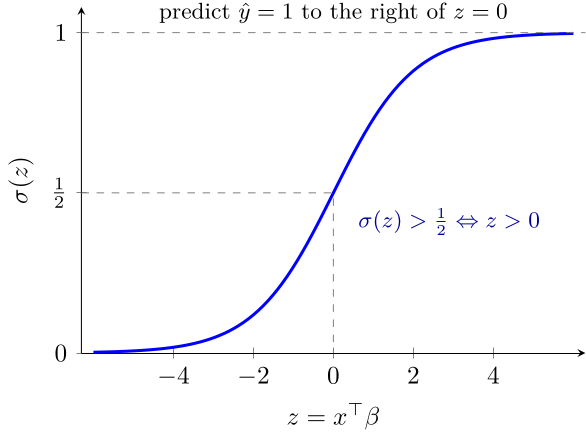

## The Likelihood

- Each $y_n$ is Bernoulli with $p_n \equiv \sigma(x_n^{\top} \beta)$, so

$$
\ell(\beta) = \sum_{n=1}^N \left[ y_n \log p_n + (1 - y_n) \log\left(1 - p_n\right) \right]
$$

- ML calls $-\ell(\beta)/N$ the **cross-entropy** or **log loss**. Minimizing it is maximizing the likelihood
- With $\sigma'(z) = \sigma(z)(1 - \sigma(z))$,

$$
\nabla \ell(\beta) = \sum_{n=1}^N (y_n - p_n)\, x_n, \qquad \nabla^2 \ell(\beta) = -\sum_{n=1}^N p_n (1 - p_n)\, x_n x_n^{\top}
$$

- As in least squares the gradient is residual times $x_n$, but $p_n$ is nonlinear in $\beta$

## A Concave Problem

- The Hessian is $-X^{\top} W X$ with $W = \mathrm{diag}(p_1 (1 - p_1), \ldots, p_N (1 - p_N))$, negative definite when $X$ has full column rank, so $\ell$ is strictly concave and any maximum is the only one (recall the definiteness lecture)
- No closed form, but Newton’s method is a sequence of weighted least squares problems

$$
\beta_{k+1} = \beta_k + \left(X^{\top} W_k X\right)^{-1} X^{\top} (y - p_k)
$$

- **Perfect separation**: if a hyperplane separates the $y = 1$ from the $y = 0$ observations, $\ell$ keeps rising as $\|\beta\| \to \infty$ and the MLE does not exist. Common with many features and few observations

## Perfect Separation: Which Line?

- Separated classes: every line between the clusters classifies the training data perfectly, and scaling any of them up pushes the likelihood toward $1$. The MLE is a whole cone of directions, not a point
- The flat directions of a semi-definite quadratic from the optimization lecture, again: the data do not pick one
- The solid line is special: it is the furthest from both clusters, the **widest margin**. Regularization picks it

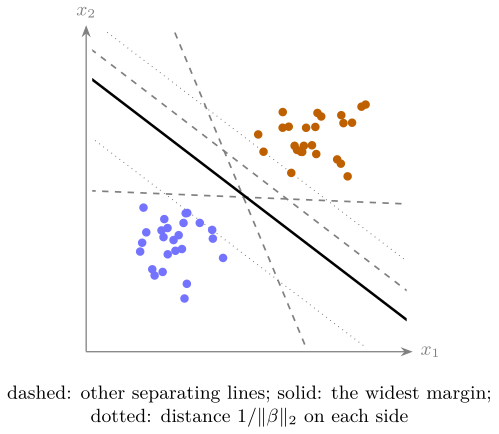

## Regularization and scikit-learn’s `C`

- `LogisticRegression` does **not** fit the MLE by default. It minimizes

$$
\frac{1}{2} \|\beta\|_2^2 - C\, \ell(\beta)
$$

- A ridge penalty with weight $1/(2C)$ on the slopes (the intercept is not penalized): **smaller `C`, more shrinkage** (default `C=1.0`). It fixes perfect separation and reduces overfitting at the cost of biased coefficients
- `C=np.inf` turns the penalty off and matches `statsmodels.Logit`; `l1_ratio=1.0` swaps in the lasso penalty $\|\beta\|_1$, which sets coefficients exactly to zero

## Regularization Picks the Widest Margin

- Along a separating direction $u$, the loss $-\ell(s\, u) \to 0$ as the scale $s \to \infty$, so with a penalty the fit trades a little loss for a smaller $\|\beta\|_2$
- The direction that clears every point by a unit with the least scale solves

$$
\min_{\beta_0, \beta} \|\beta\|_2 \,\text{s.t.}\,(2 y_n - 1)\left(\beta_0 + x_n^{\top} \beta\right) \geq 1 \text{ for all } n
$$

- The min-norm solution again. The distance from the boundary to the nearest point is $1/\|\beta\|_2$, so the smallest norm is the widest margin
- As $C \to \infty$ the ridge-penalized logistic direction converges to it ([Rosset, Zhu, and Hastie 2004](https://www.jmlr.org/papers/v5/rosset04a.html)); solving it directly is the **support vector machine**, `sklearn.svm.SVC`
- Any finite `C` lands in between: a definite answer with shrunk coefficients, as in ridge regression

## Simulated Data and Two Fits

In [6]:
rng = np.random.default_rng(526)
N = 500
X = rng.normal(size=(N, 2))
beta_true = np.array([1.5, -1.0])
p = expit(0.3 + X @ beta_true)
y = (rng.random(N) < p).astype(int)
clf = LogisticRegression(C=np.inf).fit(X, y)
print("sklearn:    ", clf.intercept_, clf.coef_[0])
logit = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
print("statsmodels:", logit.params)

sklearn:     [0.33244846] [ 1.43336144 -1.09263345]
statsmodels: [ 0.33279073  1.43333638 -1.09242626]

- Identical coefficients because `C=np.inf` turns the penalty off. Econometrics reads $\beta$ and marginal effects (`logit.get_margeff()`); ML reads predicted classes

## Predicted Classes and Probabilities

In [7]:
print(clf.predict_proba(X[:3]).round(3))
print(clf.predict(X[:10]))
print(f"accuracy on the training data: {clf.score(X, y):.3f}")

[[0.846 0.154]
 [0.113 0.887]
 [0.817 0.183]]
[0 1 0 0 1 1 1 0 1 0]
accuracy on the training data: 0.752

- `predict_proba` gives $\left[\mathbb{P}(y = 0 \,|\, x), \mathbb{P}(y = 1 \,|\, x)\right]$; `predict` applies a threshold at $1/2$

## The Decision Boundary is Linear

- $\sigma(x^{\top} \beta) > 1/2$ exactly when $x^{\top} \beta > 0$, so the boundary $\{x : x^{\top} \beta = 0\}$ is a hyperplane
- Nonlinear boundaries come from nonlinear features (polynomials, interactions, embeddings), as in least squares
- Points near the boundary have $p \approx 1/2$: that is where the mistakes are

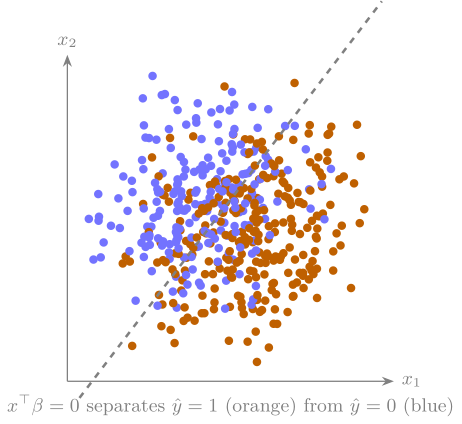

# Decision Rules and Evaluation

## The Confusion Matrix

- Cross-tabulate the true class against the predicted class on data the classifier did not see
- Rows are the truth, columns the prediction (the `sklearn` convention)
- Two kinds of mistakes with different costs: a **false positive** (predicted $1$, truly $0$) and a **false negative** (predicted $0$, truly $1$)
- The same matrix returns for k-means next lecture, where cluster labels are arbitrary

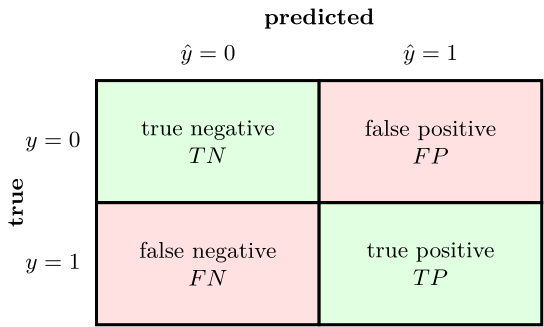

## Accuracy, Precision, and Recall

- **Accuracy** $(TP + TN) / N$; **precision** $TP / (TP + FP)$, how much to trust a predicted $1$; **recall** $TP / (TP + FN)$, how many true $1$s were found
- The **false positive rate** $FP / (FP + TN)$ and the false negative rate $1 - \text{recall}$ are the error rates $p_0$ and $p_1$ of the [last two sections](#predictions-as-measurements)

In [10]:
y_hat = clf.predict(X)
print(confusion_matrix(y, y_hat))
print(f"accuracy {clf.score(X, y):.3f}, precision "
      f"{precision_score(y, y_hat):.3f}, recall {recall_score(y, y_hat):.3f}")

[[158  67]
 [ 57 218]]
accuracy 0.752, precision 0.765, recall 0.793

## Rare Classes Break Accuracy

- With $3\%$ positives, always predicting $0$ is $97\%$ accurate and useless

In [11]:
p_rare = expit(-4.0 + X @ beta_true)
y_rare = (rng.random(N) < p_rare).astype(int)
clf_rare = LogisticRegression(C=np.inf).fit(X, y_rare)
y_hat_rare = clf_rare.predict(X)
print(f"share y = 1: {y_rare.mean():.3f}, always-zero accuracy: "
      f"{1 - y_rare.mean():.3f}, classifier accuracy: {clf_rare.score(X, y_rare):.3f}")
print(confusion_matrix(y_rare, y_hat_rare))
print(f"recall {recall_score(y_rare, y_hat_rare):.3f}")

share y = 1: 0.048, always-zero accuracy: 0.952, classifier accuracy: 0.950
[[473   3]
 [ 22   2]]
recall 0.083

- Report precision and recall whenever a class is rare, which is most variables economists want to code: a strike, a discrimination complaint, a recession

## The Threshold is a Cost Decision

- `predict` uses $\hat{y} = \mathbf{1}\left\{{\hat{p}(x) > 1/2}\right\}$. With a false positive costing $c_{FP}$ and a false negative $c_{FN}$, the cheaper prediction is $\hat{y} = 1$ when

$$
\hat{p}(x) > \frac{c_{FP}}{c_{FP} + c_{FN}} \equiv \tau
$$

- Equal costs give $\tau = 1/2$; if a miss is nine times worse than a false alarm, $\tau = 0.1$
- $\hat{p}(x)$ estimates the **posterior** $\mathbb{P}(y = 1 \,|\, x)$ of the probability lecture. Logistic regression models it directly; **generative** classifiers such as naive Bayes model $\mathbb{P}(x \,|\, y)$ and $\mathbb{P}(y)$ and use Bayes’ law
- Lowering $\tau$ raises recall at the expense of false alarms; `class_weight="balanced"` pushes the fit the same way

## The ROC Curve

- Sweep $\tau$ from $1$ to $0$ and plot recall against the false positive rate: the **receiver operating characteristic**. $\tau = 1$ flags nothing, $\tau = 0$ flags everything, a coin flip traces the diagonal
- Every point is a threshold you could choose: the whole recall-versus-false-alarm menu, before any cost is decided
- The **area under the curve** (AUC) is the probability that a random true $1$ scores above a random true $0$: a grade for the ranking, independent of $\tau$

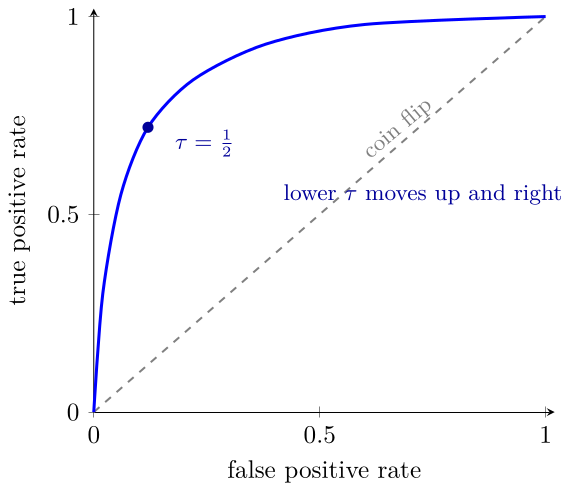

## ROC in Code: the Rare Class Ranks Fine

- `RocCurveDisplay` draws the sweep from `predict_proba`; `roc_auc_score` integrates it

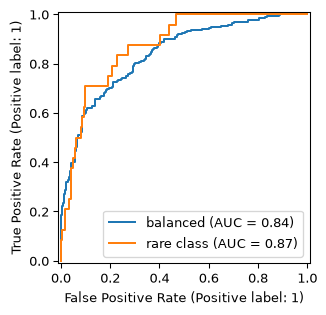

tau = 0.5: recall 0.08
tau = 0.1: recall 0.71

In [13]:
fig, ax = plt.subplots(figsize=(4.5, 3.4))
s_bal = clf.predict_proba(X)[:, 1]
s_rare = clf_rare.predict_proba(X)[:, 1]
RocCurveDisplay.from_predictions(
    y, s_bal, ax=ax, name="balanced")
RocCurveDisplay.from_predictions(
    y_rare, s_rare, ax=ax, name="rare class")
plt.show()
for tau in [0.5, 0.1]:
    y_hat = (s_rare > tau).astype(int)
    print(f"tau = {tau}: recall "
          f"{recall_score(y_rare, y_hat):.2f}")

- The rare-class classifier has the **higher** AUC: it ranks the positives well and only the default threshold was wrong; at $\tau = 0.1$ it finds most of them. For a rare class the precision-recall curve (`PrecisionRecallDisplay`) is the more demanding picture

## Train, Test, and Overfitting

- Fit on a **training** set, evaluate on a **test** set the fit never touched. Tune anything (`C`, the threshold, the features) on a separate validation set, or the test set stops being one
- Add $200$ noise features: the MLE fits the training half perfectly and the test half badly

In [14]:
X_noise = np.hstack([X, rng.normal(size=(N, 200))])
X_tr, X_te, y_tr, y_te = train_test_split(X_noise, y, test_size=0.5,
                                          random_state=526)
mle = LogisticRegression(C=np.inf, max_iter=5000).fit(X_tr, y_tr)
lasso = LogisticRegression(l1_ratio=1.0, solver="liblinear", C=0.1).fit(X_tr, y_tr)
oracle = LogisticRegression(C=np.inf).fit(X_tr[:, :2], y_tr)
print(f"MLE:    train {mle.score(X_tr, y_tr):.3f}  test {mle.score(X_te, y_te):.3f}")
print(f"lasso:  train {lasso.score(X_tr, y_tr):.3f}  test {lasso.score(X_te, y_te):.3f}"
      f"  nonzero {(lasso.coef_ != 0).sum()} of {X_noise.shape[1]}")
print(f"oracle: test {oracle.score(X_te[:, :2], y_te):.3f} (the two true features)")

MLE:    train 1.000  test 0.640
lasso:  train 0.788  test 0.736  nonzero 19 of 202
oracle: test 0.740 (the two true features)

- The lasso drops most of the noise features and nearly matches the model that knows which two matter

# More Than Two Classes

## Multinomial Logit, the Softmax, and Random Utility

- With $K$ classes, give each its own $\beta_k \in {\mathbb{R}}^M$ and apply the **softmax**

$$
\mathbb{P}(y = k \,|\, x) = \frac{e^{x^{\top} \beta_k}}{\sum_{j=1}^K e^{x^{\top} \beta_j}}
$$

- Only differences $\beta_k - \beta_j$ matter, so one class is normalized to $\beta_1 = 0$; with $K = 2$ this is the sigmoid. The log-likelihood is still concave, and `LogisticRegression` fits it automatically when `y` has more than two values
- Economists reached the same formula through **discrete choice** (McFadden 1974): an agent picks the option with the highest utility $U_k = x^{\top} \beta_k + \epsilon_k$ with i.i.d. Gumbel $\epsilon_k$, and $\mathbb{P}(\text{choose } k \,|\, x)$ is the softmax
- The same map from a score per option to a distribution is how a language model picks the next token, with $K$ the vocabulary size

# Application: Coding Occupations from Job Titles

## The Problem

- Payroll files, postings, and surveys carry free-text titles: `POLICE OFFICER`, `SR DATA ANALYST`, `Chief Diversity Officer (CDO)`. Analysis wants a Standard Occupational Classification (SOC) code, whose first two digits give one of $23$ **major groups**
- Hand-coding is slow and inconsistent, so **code a labelled sample and classify the rest**. [O\*NET](https://www.onetcenter.org/database.html) publishes $8{,}189$ worker-reported titles with their SOC code

## Bag of Words

- The simplest feature map counts how often each vocabulary word appears, ignoring order. `CountVectorizer` builds the vocabulary from the training titles and returns a sparse matrix with one column per word

In [15]:
demo = CountVectorizer().fit(["Police Officer", "Police Sergeant", "Chief Officer"])
print(demo.get_feature_names_out())
print(demo.transform(["Police Officer", "Police Sergeant"]).toarray())

['chief' 'officer' 'police' 'sergeant']
[[0 1 1 0]
 [0 0 1 1]]

- Words never seen in training are dropped at prediction time. The text lecture adds weighting and embeddings; counting is enough here

## Loading the Data

- The data files live in `slides/data/` of the course repository. The notebooks read a local copy if there is one and the course website otherwise

In [16]:
def data_path(name):
    url = "https://jlperla.github.io/grad_econ_datascience/slides/data/"
    return f"data/{name}" if os.path.exists(f"data/{name}") else url + name

onet = pd.read_csv(data_path("onet_titles.csv.gz"))
sample = onet.sample(4, random_state=1)[["title", "soc_code", "major_group_title"]]
print(sample.to_string(index=False))
print(onet["major_group_title"].value_counts().head(4))

                                      title   soc_code                      major_group_title
              MHA (Mental Health Assistant) 29-2053.00 Healthcare Practitioners and Technical
                            Line Supervisor 51-1011.00                             Production
Home Care Physical Therapist (Home Care PT) 29-1123.00 Healthcare Practitioners and Technical
                  Licensed Reactor Operator 51-8011.00                             Production
major_group_title
Production                                1016
Healthcare Practitioners and Technical     734
Educational Instruction and Library        613
Construction and Extraction                534
Name: count, dtype: int64

## Fitting the Coder

- Word counts of the title, the major group as the label ($22$ classes), a quarter of the titles held out

In [17]:
vec = CountVectorizer()
X_onet = vec.fit_transform(onet["title"])
y_onet = onet["major_group_title"]
X_tr, X_te, y_tr, y_te = train_test_split(X_onet, y_onet, test_size=0.25,
                                          random_state=526)
coder = LogisticRegression(solver="newton-cg").fit(X_tr, y_tr)
print(f"vocabulary size {X_onet.shape[1]}, classes {len(coder.classes_)}")
print(f"train accuracy {coder.score(X_tr, y_tr):.3f}, "
      f"test accuracy {coder.score(X_te, y_te):.3f}")

vocabulary size 3355, classes 22
train accuracy 0.861, test accuracy 0.719

- `newton-cg` is the Newton iteration from earlier; the default solver is ten times slower here. Train well above test: overfitting again

## Where Does it Go Wrong?

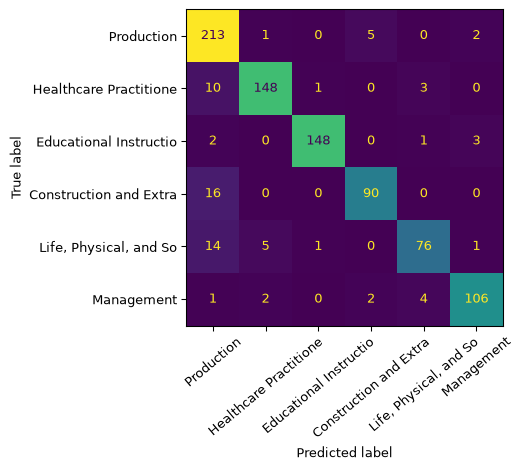

In [18]:
top = y_onet.value_counts().index[:6]
ConfusionMatrixDisplay.from_predictions(
    y_te, coder.predict(X_te), labels=top,
    display_labels=[t[:22] for t in top],
    xticks_rotation=40, colorbar=False)
plt.tight_layout()
plt.show()

- The six largest groups on held-out titles. The off-diagonal mistakes are between groups whose titles share words

## Coding a Payroll File

- Apply the coder to $8{,}000$ full-time salaried positions from the City of Chicago’s payroll

In [19]:
chicago = pd.read_csv(data_path("chicago_payroll.csv.gz"))
X_chicago = vec.transform(chicago["job_title"])
chicago["group"] = coder.predict(X_chicago)
chicago["p_max"] = coder.predict_proba(X_chicago).max(axis=1).round(2)
counts = chicago.groupby(["job_title", "group"])["p_max"].agg(n="size", p_max="first")
print(counts.sort_values("n", ascending=False).head(8).to_string())

                                                                                  n  p_max
job_title                              group                                              
POLICE OFFICER                         Protective Service                      2465   0.89
FIREFIGHTER-EMT                        Healthcare Practitioners and Technical   550   0.18
SERGEANT                               Production                               447   0.15
POLICE OFFICER (ASSIGNED AS DETECTIVE) Protective Service                       376   0.99
FIREFIGHTER-EMT (RECRUIT)              Healthcare Practitioners and Technical   171   0.18
LIEUTENANT-EMT                         Protective Service                       144   0.13
FIRE ENGINEER-EMT                      Architecture and Engineering             141   0.75
PARAMEDIC                              Healthcare Practitioners and Technical   132   0.22

- Chicago’s titles use a different dialect: `FIREFIGHTER-EMT` is coded by its second word, and a title with no known word gets the largest-intercept group. Check the common titles and `p_max` before using the codes

## The Regression the Codes Were Built For

In [20]:
premia = smf.ols("np.log(annual_salary) ~ C(group) + C(department)",
                 data=chicago).fit()
coef = premia.params.filter(like="group").round(2)
coef.index = coef.index.str.replace(r"C\(group\)\[T\.(.*)\]", r"\1", regex=True)
print(pd.concat([coef.nsmallest(4), coef.nlargest(4)]).to_string())

Building and Grounds Cleaning and Maintenance   -0.38
Healthcare Support                              -0.29
Healthcare Practitioners and Technical          -0.20
Office and Administrative Support               -0.18
Personal Care and Service                        0.26
Educational Instruction and Library              0.19
Management                                       0.19
Production                                       0.19

- Log-salary differences relative to Architecture and Engineering within a department, the four lowest and four highest
- Plausible magnitudes, but the regressor is a classifier’s output with about $25\%$ of titles miscoded on held-out data: **measurement error in a regressor**. What does it do to the coefficients?

# Predictions as Measurements

## A Classifier is a Measuring Instrument

- The regression wants the true $d_n$ (an occupation, a topic, a land use) and gets the classifier’s $\hat{d}_n$. The gap is **measurement error**, and the confusion matrix on a random labelled sample is its error model: the false positive rate $p_0$ and the false negative rate $p_1$
- Mistakes unrelated to everything else in the regression shrink the coefficient toward zero by a factor of about $1 - p_0 - p_1$: **attenuation**, no sign flip, unchanged as $N$ grows
- Mistakes that vary with the regressors (a region, a period, a subgroup with a different base rate, the wording of a prompt) are **differential** and bias in either direction. This is the case to worry about

## What to Do About It

- Keep a **random labelled sample**, report its confusion matrix with the regression, and never treat classifier output as truth
- Check the error rates by subgroup before trusting a correction; the [text lecture](text_classification.qmd#/correcting-the-coverage-regression) does this on Newswire
- Corrections exist, from a division by $1 - p_0 - p_1$ to the `ValidMLInference` package of Battaglia, Christensen, Hansen, and Sacher (2024). The [optional section](#measurement-error-from-a-classifier) derives the attenuation for a regressor and for an outcome, checks it by simulation, and lists them

# Measurement Error from a Classifier

## A Mismeasured Regressor (Aigner 1973)

- The true $d_n \in \{0, 1\}$ enters $y_n = \alpha + \beta\, d_n + u_n$, but we observe the classifier’s $\hat{d}_n$, with the error rates of its confusion matrix

$$
p_0 \equiv \mathbb{P}(\hat{d}_n = 1 \,|\, d_n = 0), \qquad p_1 \equiv \mathbb{P}(\hat{d}_n = 0 \,|\, d_n = 1)
$$

- If the mistakes are **non-differential** (given $d_n$, independent of $u_n$ and the other regressors), OLS on $\hat{d}_n$ converges to

$$
\hat{\beta} \approx \beta \cdot \lambda, \qquad \lambda \approx 1 - p_0 - p_1
$$

- For any classifier better than a coin flip ($p_0 + p_1 < 1$), $\lambda$ is between $0$ and $1$: **attenuation** toward zero, never a sign flip, unchanged as $N$ grows

## Monte Carlo

In [21]:
def attenuation(N, p0, p1, pi=0.3, beta=1.0, reps=100):
    slopes = []
    for _ in range(reps):
        d = rng.random(N) < pi
        y = 2.0 + beta * d + rng.normal(size=N)
        d_hat = np.where(d, rng.random(N) > p1, rng.random(N) < p0).astype(float)
        slopes.append(sm.OLS(y, sm.add_constant(d_hat)).fit().params[1])
    return np.mean(slopes)

for N in [1_000, 10_000, 100_000]:
    print(f"N = {N:>7,}: mean slope {attenuation(N, 0.05, 0.20):.3f}")
pi, q = 0.3, 0.3 * 0.8 + 0.7 * 0.05
print(f"1 - p0 - p1 = {0.75:.3f}, exact factor {0.75 * pi * (1 - pi) / (q * (1 - q)):.3f}")

N =   1,000: mean slope 0.789
N =  10,000: mean slope 0.789
N = 100,000: mean slope 0.789
1 - p0 - p1 = 0.750, exact factor 0.790

- True $\beta = 1$. The estimate sits at the exact factor $(1 - p_0 - p_1)\, \pi(1 - \pi) / (q(1 - q))$, with $q$ the predicted share of ones, and does not move with $N$

## A Mismeasured Outcome

- Now the classifier’s output is the **outcome**: the regression wants $y_n \in \{0, 1\}$ and gets $\tilde{y}_n$, with a false positive rate $p_0$ and a false negative rate $p_1$ that do not depend on $x_n$

$$
{\mathbb{E}}[\tilde{y}_n \,|\, x_n] = p_0 + (1 - p_0 - p_1)\, {\mathbb{E}}[y_n \,|\, x_n]
$$

- Every coefficient shrinks by exactly the factor $1 - p_0 - p_1$ (the regressor case had an approximation), and the intercept also picks up $p_0$. Dividing the slopes by the factor undoes it
- The [text lecture](text_classification.qmd#/correcting-the-coverage-regression) applies the division to a coverage regression on Newswire, where the outcome is a topic classifier’s label

## Differential Errors

- Both results assume error rates that do not depend on the regressors. A subgroup with a different base rate, a region whose images look unlike the training set, a season, the wording of a prompt: each breaks the assumption
- Dividing by $1 - p_0 - p_1$ can then overshoot: **differential** errors bias in either direction, not only toward zero
- Diagnose it with the confusion matrix **by subgroup**, so the labelled sample has to cover the subgroups the regression compares

## Corrections Exist

- The held-out confusion matrix estimates $p_0$ and $p_1$, so the attenuation can be undone. Three to know about
  - **Battaglia, Christensen, Hansen, and Sacher (2024)**: correct the moments with the validation-sample error rates; package [`ValidMLInference`](https://github.com/MTChristensen/ValidMLInference)
  - **Prediction-powered inference** (Angelopoulos et al. 2023): combine predictions on the full sample with the labelled sample into an unbiased estimator
  - **Design-based supervised learning** (Egami, Hinck, Stewart, and Wei 2023): the same idea for text, with the labelled sample drawn at random from the corpus
- All three rest on a **random labelled sample** from the same population as the regression: it is the only evidence on the classifier’s errors, and the only place differential error can show up